## Mediocre ML Model for Humanity Score

In [24]:
import numpy as np
import pandas as pd
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from keras.layers import Normalization
import os
import json

In [25]:
def handle_data(data, labels, max_length):
    new_data, new_labels = [], []
    for idx, session in enumerate(data):
        cur_label = labels[idx]
        session_length = len(session)
        cur = 0
        while cur * max_length + max_length <= session_length:
            new_data.append(session[cur * max_length: (cur + 1) * max_length])
            new_labels.append(cur_label)
            cur += 1
        
        last_section = session[cur * max_length:]
        last_section += [session[-1] for _ in range(max_length - len(last_section))]
        new_data.append(last_section)
        new_labels.append(cur_label)

    new_data, new_labels = np.array(new_data), np.array(new_labels)
    layer = Normalization(axis=1)
    layer.adapt(new_data)
    return new_data, new_labels

def load(path="mydata/data", max_length=100):
    files = os.listdir(path)
    data = []
    labels = []
    for file in files:
        with open(os.path.join(path, file), "r") as f:
            dct = json.load(f)
        mouse = dct["mouse_movements"]
        if not mouse:
            continue
        entry = [[i['x'], i['y']] for i in mouse]
        data.append(entry)
        
        if file.startswith("human"):
            labels.append(0)
        elif file.startswith("bot_N"):
            labels.append(1)
        elif file.startswith("bot_H"):
            labels.append(2)
        elif file.startswith("bot_M"):
            labels.append(3)
        elif file.startswith("bot_F"):
            labels.append(4)

    data, labels = handle_data(data, labels, max_length=max_length)
    return data, labels

x_train, y_train = load(max_length=100, path="../train_data")
x_test, y_test = load(max_length=100, path="../data")

In [26]:
n_timesteps, n_features = x_train.shape[1], x_train.shape[2]
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((239, 100, 2), (239,), (283, 100, 2), (283,))

In [27]:
Y_train = np.where(y_train > 0, 1, y_train)
Y_test = np.where(y_test > 0, 1, y_test)

### Balabit Loading

In [28]:
import os
import numpy as np
import pandas as pd

MIN_DT = 0.01  # 10 ms


def load_session(file_path):
    """
    Load a single session file and return filtered [x, y] numpy array.
    """
    df = pd.read_csv(file_path)

    # Ensure correct column names
    df.columns = [
        "record_ts", "client_ts", "button", "state", "x", "y"
    ]

    # Sort by timestamp (important)
    df = df.sort_values("client_ts").reset_index(drop=True)

    # Filter by minimum time difference
    selected_indices = [0]
    last_time = df.loc[0, "client_ts"]

    for i in range(1, len(df)):
        current_time = df.loc[i, "client_ts"]
        if current_time - last_time >= MIN_DT:
            selected_indices.append(i)
            last_time = current_time

    df_filtered = df.loc[selected_indices]

    # Extract features
    features = df_filtered[["x", "y"]].to_numpy(dtype=np.float32)

    return features


def load_dataset(data_dir, split="training_files"):
    """
    Load entire dataset (training or testing).
    
    Returns:
        dict: {user: [session_arrays]}
    """
    split_path = os.path.join(data_dir, split)
    dataset = {}

    for user in os.listdir(split_path):
        user_path = os.path.join(split_path, user)

        if not os.path.isdir(user_path):
            continue

        sessions = []

        for session_file in os.listdir(user_path):
            # if not session_file.endswith(".csv"):
            #     continue

            file_path = os.path.join(user_path, session_file)

            features = load_session(file_path)
            sessions.append(features)

        dataset[user] = sessions

    return dataset


# Example usage
data_dir = "./balabit_dataset"

train_data = load_dataset(data_dir, "training_files")
test_data = load_dataset(data_dir, "test_files")

train_data, test_data

({'user12': [array([[1043.,  410.],
          [1024.,  410.],
          [ 979.,  409.],
          ...,
          [1006.,  471.],
          [1012.,  466.],
          [1013.,  466.]], shape=(27542, 2), dtype=float32),
   array([[ 619.,  566.],
          [ 633.,  571.],
          [ 630.,  578.],
          ...,
          [1131.,  331.],
          [1131.,  331.],
          [1131.,  331.]], shape=(30242, 2), dtype=float32),
   array([[158., 370.],
          [158., 370.],
          [160., 370.],
          ...,
          [419., 665.],
          [419., 665.],
          [419., 665.]], shape=(46201, 2), dtype=float32),
   array([[269., 790.],
          [400., 777.],
          [631., 770.],
          ...,
          [620., 260.],
          [612., 260.],
          [612., 260.]], shape=(23095, 2), dtype=float32),
   array([[298.,  53.],
          [305.,  51.],
          [309.,  50.],
          ...,
          [656., 359.],
          [656., 358.],
          [656., 358.]], shape=(29867, 2), dtype=float3

In [29]:
SEG_LEN = 100

def segment_sessions(dataset, seg_len=SEG_LEN, stride=None):
    """
    Convert sessions into fixed-length segments.

    Args:
        dataset: dict {user: [session_arrays]}
        seg_len: length of each segment (default=100)
        stride: step size (default = seg_len, i.e., no overlap)

    Returns:
        segments: list of np.array (seg_len, 2)
        labels: list of user labels
    """
    if stride is None:
        stride = seg_len  # non-overlapping

    segments = []

    for user, sessions in dataset.items():
        for session in sessions:
            n = len(session)

            # Slide window
            for start in range(0, n - seg_len + 1, stride):
                seg = session[start:start + seg_len]

                if len(seg) == seg_len:
                    segments.append(seg)

    return np.array(segments, dtype=np.float32)


# Example usage
balabit_x_train = segment_sessions(train_data, seg_len=100)
balabit_y_train = np.zeros((balabit_x_train.shape[0],))

balabit_x_test = segment_sessions(test_data, seg_len=100)
balabit_y_test = np.zeros((balabit_x_test.shape[0],))

print(balabit_x_train.shape, balabit_y_train.shape)  # (num_segments, 100, 2)
print(balabit_x_test.shape, balabit_y_test.shape)  # (num_segments, 100, 2)

(19053, 100, 2) (19053,)
(19344, 100, 2) (19344,)


In [60]:
import tensorflow as tf
file = "models/big_model.keras"
model = tf.keras.models.load_model(file)
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_15 (LSTM)                  │ (None, 100, 200)       │       162,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_16 (LSTM)                  │ (None, 100)            │       120,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 912,149 (3.48 MB)

 Trainable params: 304,049 (1.16 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 608,100 (2.32 MB)

In [ ]:
import keras
from keras.optimizers import Adam

verbose, epochs, batch_size = 2, 10, 64
model.compile(
    optimizer=Adam(learning_rate=1e-4), 
    loss=keras.losses.BinaryFocalCrossentropy(),
    metrics=['accuracy']
)
# model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(balabit_x_train, balabit_y_train, epochs=epochs, batch_size=batch_size, verbose=verbose)

In [31]:
_, accuracy = model.evaluate(balabit_x_test, balabit_y_test, batch_size=128, verbose=0)
print(f"Testing: {accuracy:.2%}")

Testing: 89.25%


In [32]:
full_train_x, full_test_x, full_train_y, full_test_y = np.concat([balabit_x_train, x_train]), np.concat([balabit_x_test, x_test]), np.concat([balabit_y_train, Y_train]), np.concat([balabit_y_test, Y_test])
full_train_x.shape, full_test_x.shape, full_train_y.shape, full_test_y.shape

((19292, 100, 2), (19627, 100, 2), (19292,), (19627,))

In [48]:
(full_train_y==1).sum()

np.int64(156)

In [63]:
import tensorflow as tf
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',      # metric to monitor
    patience=1,              # epochs to wait before stopping
    restore_best_weights=True
)

def weighted_bce(pos_weight):
    def loss(y_true, y_pred):
        return tf.nn.weighted_cross_entropy_with_logits(
            labels=y_true,
            logits=y_pred,
            pos_weight=pos_weight
        )
    return loss

def class_balanced_loss(beta, samples_per_class):
    effective_num = 1.0 - tf.pow(beta, samples_per_class)
    weights = (1.0 - beta) / effective_num
    weights /= tf.reduce_sum(weights) * len(samples_per_class)
    def loss(y_true, y_pred):
        weights_per_sample = tf.reduce_sum(weights * y_true, axis=-1)
        ce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        return weights_per_sample * ce
    return loss

verbose, epochs, batch_size = 2, 1, 64
model.compile(
    optimizer=Adam(learning_rate=1e-6),
    loss=keras.losses.BinaryFocalCrossentropy(),
    # loss=class_balanced_loss(beta=0.999, samples_per_class=[100, 1]), #weighted_bce(pos_weight=50.0),
    metrics=['accuracy']
)
# model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])  # validation_data=(full_test_x, full_test_y)
model.fit(full_train_x, full_train_y, epochs=epochs, batch_size=batch_size, verbose=verbose, validation_data=(x_test, Y_test), callbacks=[early_stop])

302/302 - 68s - 225ms/step - accuracy: 0.9281 - loss: 0.1009 - val_accuracy: 0.8445 - val_loss: 0.3194


In [64]:
_, accuracy = model.evaluate(full_test_x, full_test_y, batch_size=128, verbose=0)
print(f"Full Testing: {accuracy:.2%}")

_, accuracy = model.evaluate(balabit_x_test, balabit_y_test, batch_size=128, verbose=0)
print(f"Balabit Testing: {accuracy:.2%}")

# Evaluate model
batch_size = 128

_, accuracy = model.evaluate(x_train, Y_train, batch_size=batch_size, verbose=0)
print(f"My Training: {accuracy:.2%}")

_, accuracy = model.evaluate(x_test, Y_test, batch_size=batch_size, verbose=0)
print(f"My Testing: {accuracy:.2%}")

Full Testing: 95.02%
Balabit Testing: 95.18%
My Training: 88.28%
My Testing: 84.45%


In [ ]:
# Evaluate model
batch_size = 128

_, accuracy = model.evaluate(x_train, Y_train, batch_size=batch_size, verbose=0)
print(f"My Training: {accuracy:.2%}")

_, accuracy = model.evaluate(x_test, Y_test, batch_size=batch_size, verbose=0)
print(f"My Testing: {accuracy:.2%}")

My Training: 76.99%
My Testing: 66.43%


### Done ig

In [ ]:
# Evaluate model
batch_size = 128

_, accuracy = model.evaluate(x_train, Y_train, batch_size=batch_size, verbose=0)
print(f"My Training: {accuracy:.2%}")

_, accuracy = model.evaluate(x_test, Y_test, batch_size=batch_size, verbose=0)
print(f"My Testing: {accuracy:.2%}")

My Training: 76.99%
My Testing: 66.43%


In [36]:
import tensorflow as tf
file = "models/big_model.keras"
model = tf.keras.models.load_model(file)
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_15 (LSTM)                  │ (None, 100, 200)       │       162,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_16 (LSTM)                  │ (None, 100)            │       120,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 912,149 (3.48 MB)

 Trainable params: 304,049 (1.16 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 608,100 (2.32 MB)

In [23]:
import keras
from keras.optimizers import Adam

verbose, epochs, batch_size = 2, 10, 64

# To change both the optimizer and learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-4), 
    loss=keras.losses.BinaryFocalCrossentropy(),
    metrics=['accuracy']
)

# model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model.fit(x_train, Y_train, epochs=epochs, batch_size=batch_size, verbose=verbose)

# Evaluate model
_, accuracy = model.evaluate(x_train, Y_train, batch_size=batch_size, verbose=0)
print(f"Training: {accuracy:.2%}")

_, accuracy = model.evaluate(x_test, Y_test, batch_size=batch_size, verbose=0)
print(f"Testing: {accuracy:.2%}")

Epoch 1/10
4/4 - 3s - 664ms/step - accuracy: 0.9791 - loss: 0.0310
Epoch 2/10
4/4 - 1s - 149ms/step - accuracy: 0.9791 - loss: 0.0267
Epoch 3/10
4/4 - 1s - 159ms/step - accuracy: 0.9833 - loss: 0.0107
Epoch 4/10
4/4 - 1s - 154ms/step - accuracy: 0.9958 - loss: 0.0063
Epoch 5/10
4/4 - 1s - 175ms/step - accuracy: 0.9874 - loss: 0.0098
Epoch 6/10
4/4 - 1s - 175ms/step - accuracy: 0.9916 - loss: 0.0059
Epoch 7/10
4/4 - 1s - 181ms/step - accuracy: 0.9958 - loss: 0.0039
Epoch 8/10
4/4 - 1s - 182ms/step - accuracy: 0.9958 - loss: 0.0034
Epoch 9/10
4/4 - 1s - 189ms/step - accuracy: 0.9958 - loss: 0.0030
Epoch 10/10
4/4 - 1s - 196ms/step - accuracy: 0.9958 - loss: 0.0026
Training: 99.58%
Testing: 85.16%


(219, 100, 2) (219,)
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step


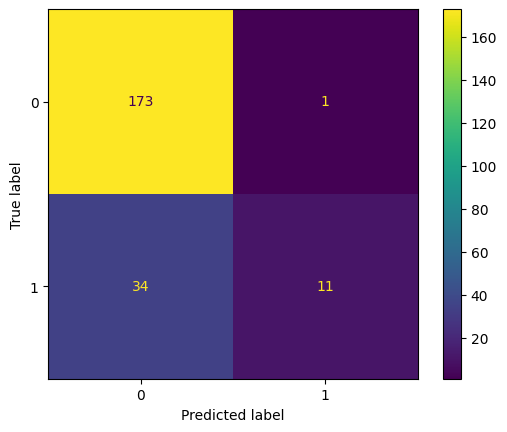

In [20]:
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay

id = 4

idx = np.concatenate((np.where(y_test == 0), np.where(y_test == id)), axis=1)

x = x_test[idx].squeeze()
y = y_test[idx].squeeze()

y = np.where(y==id, 1, y)

print(x.shape, y.shape)

ConfusionMatrixDisplay.from_predictions(y, np.round(model.predict(x)))

614/614 ━━━━━━━━━━━━━━━━━━━━ 24s 39ms/step


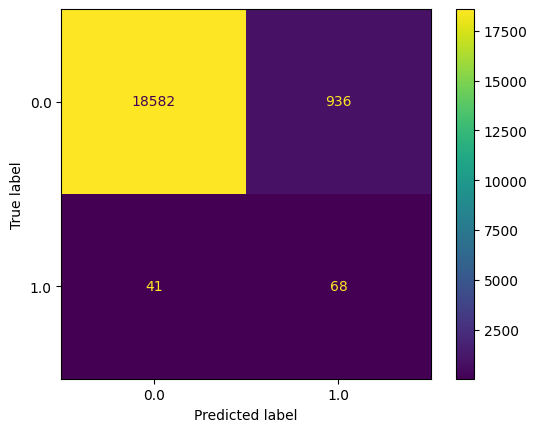

In [65]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(full_test_y, np.round(model.predict(full_test_x)))

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step


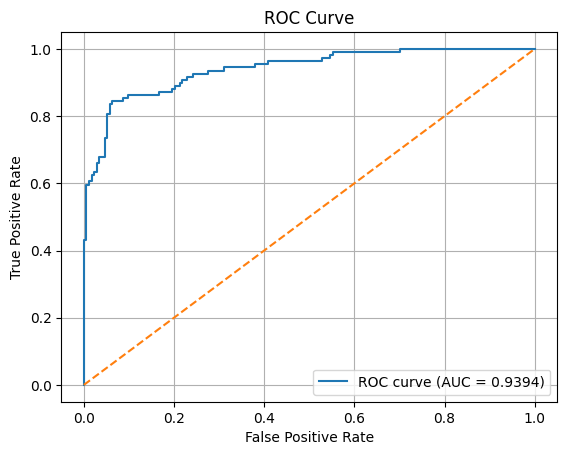

In [66]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

x, y = x_test, Y_test

# Get predicted probabilities for the positive class
y_scores = model.predict(x)  
# If your model doesn't support predict_proba, use:
# y_scores = model.decision_function(X_train)

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y, y_scores)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")  # random classifier line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


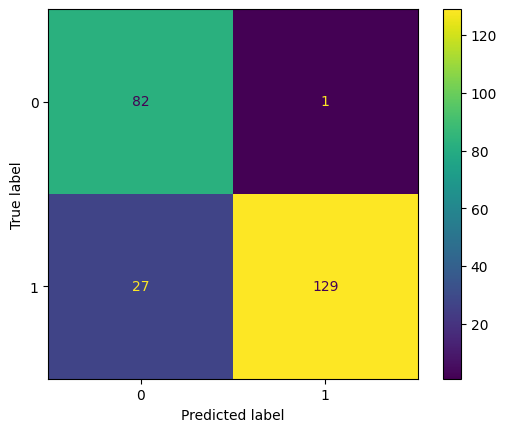

In [67]:
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay

# id = 4

# idx = np.concatenate((np.where(y_train == 0), np.where(y_train == id)), axis=1)

# x = x_train[idx].squeeze()
# y = y_train[idx].squeeze()

# y = np.where(y==id, 1, y)

# print(x.shape, y.shape)

ConfusionMatrixDisplay.from_predictions(Y_train, np.round(model.predict(x_train)))

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


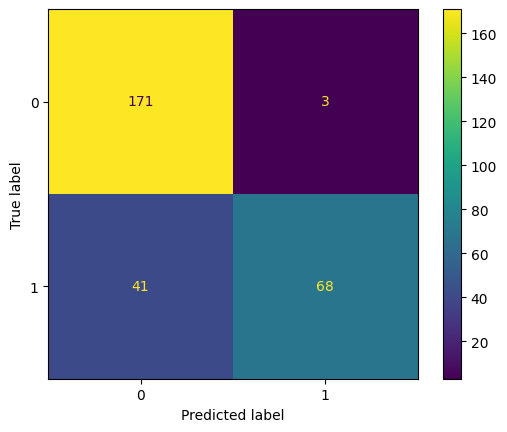

In [68]:
ConfusionMatrixDisplay.from_predictions(Y_test, np.round(model.predict(x_test)))